## Phase 1 : Data Cleaning

### Importing Libraries and Loading Data:

In [2]:
pip install pandas numpy matplotlib seaborn jupyter

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached jupyter-1.1.1-py2.py3-none-any.whl (2.7 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
Using cached jupyter_console-6.6.3-py3-none-any.whl (24 kB)

   ------------- -------------------------- 2/6 [seaborn]
   ------------- -------------------------- 2/6 [seaborn]
   ------------- --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Loading dataset
df = pd.read_csv(r'..\data\Student_Performance.csv')
print(df.shape)
df.head()

(25000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


### Understanding the data:

In [23]:
df.info()          # column types and null counts
df.describe()      # statistics summary
df.isnull().sum()  # count missing values per column

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

### Removing Duplicates:

In [24]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before: (25000, 16)
After removing duplicates: (15000, 16)


### Handling Missing Values:

In [30]:
warnings.filterwarnings("ignore")

# Even though we dont have missing values, we perform this handle missing data in updated future dataset

# Filling missing attendance_percentage with the median (safer than mean for outliers)
df['attendance_percentage'].fillna(df['attendance_percentage'].median(), inplace=True)

# Filling missing parent_education with 'Unknown'
df['parent_education'].fillna('Unknown', inplace=True)

# Filling missing overall_score with column mean
df['overall_score'].fillna(df['overall_score'].mean(), inplace=True)

df.isnull().sum()  # confirm no nulls remain


student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

### Fixing Wrong Grade Formats:

In [31]:
# If final_grade column has mixed values like 'A', 'B', 'absent', '90'
df['final_grade'] = df['final_grade'].replace({ 90: 'a', 80 : 'b', 70 : 'c', 60 : 'd', 50 : 'e', 40 :'f',
'A' : 'a', 'B' : 'b', 'C' : 'c', 'D' : 'd', 'E' : 'e', 'F' :'f',  'absent': np.nan})

### Removing Outliners using Inter Quartile Range ( IQR ):

In [32]:
Q1 = df['overall_score'].quantile(0.25)
Q3 = df['overall_score'].quantile(0.75)
IQR = Q3 - Q1

# Keeping only rows within acceptable range
df = df[(df['overall_score'] >= Q1 - 1.5 * IQR) & 
        (df['overall_score'] <= Q3 + 1.5 * IQR)]

print("After removing outliers:", df.shape)

After removing outliers: (15000, 16)


### Saving the Cleaned Dataset:

In [38]:
df.to_csv(r'..\data\cleaned_data.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


## Phase 2 : Exploratory Data Analysis ( EDA )

### Does attendance affect marks?

Correlation (attendance, overall_score): 0.293


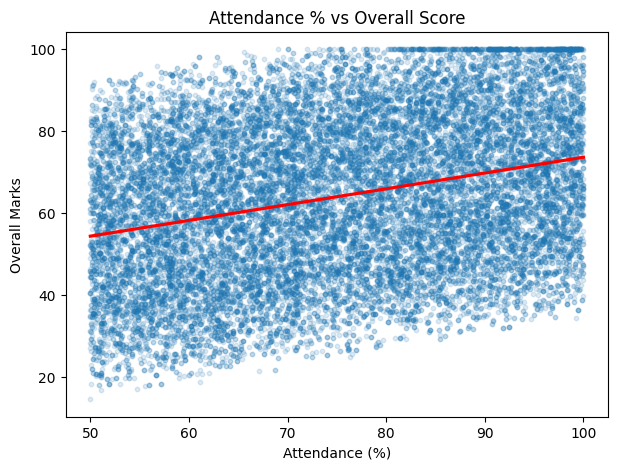

In [53]:
# We express this in a scatterplot: 

print("Correlation (attendance, overall_score):", round(df['attendance_percentage'].corr(df['overall_score']), 3))

plt.figure(figsize=(7,5))
sns.regplot(data=df, x='attendance_percentage', y='overall_score', scatter_kws={'alpha':0.15,'s':10}, line_kws={'color':'red'})
plt.title('Attendance % vs Overall Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Overall Marks')
plt.savefig(r'..\reports\attendance_vs_marks.png')
plt.show()

### Does parent education affect performance?

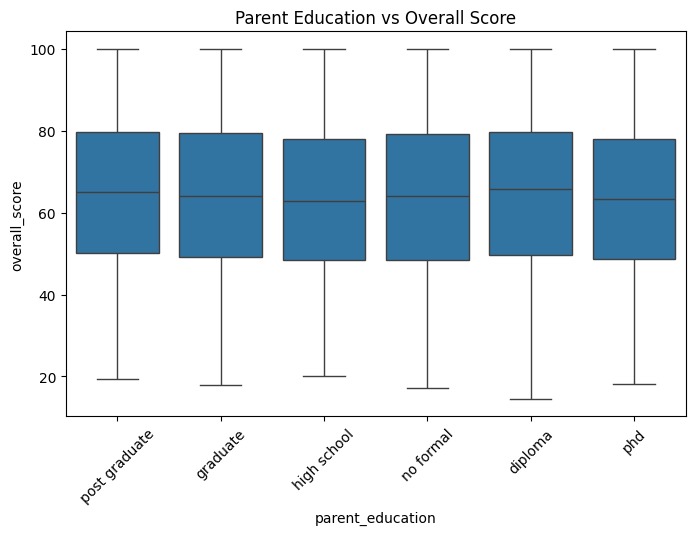

In [42]:
# We use Box plot to express this relation:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='parent_education', y='overall_score')
plt.title('Parent Education vs Overall Score')
plt.xticks(rotation=45)
plt.savefig('../reports/parentedu_vs_marks.png')
plt.show()

### Does internet access improve scores?

internet_access
no     63.774821
yes    64.047294
Name: overall_score, dtype: float64


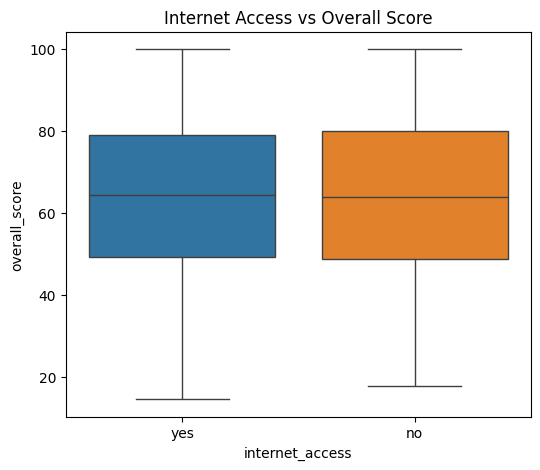

In [54]:
# We express the relation in Boxplot:

print(df.groupby('internet_access')['overall_score'].mean())

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='internet_access', y='overall_score', hue='internet_access', legend=False)
plt.title('Internet Access vs Overall Score')
plt.show()

### Correlation heatmap:

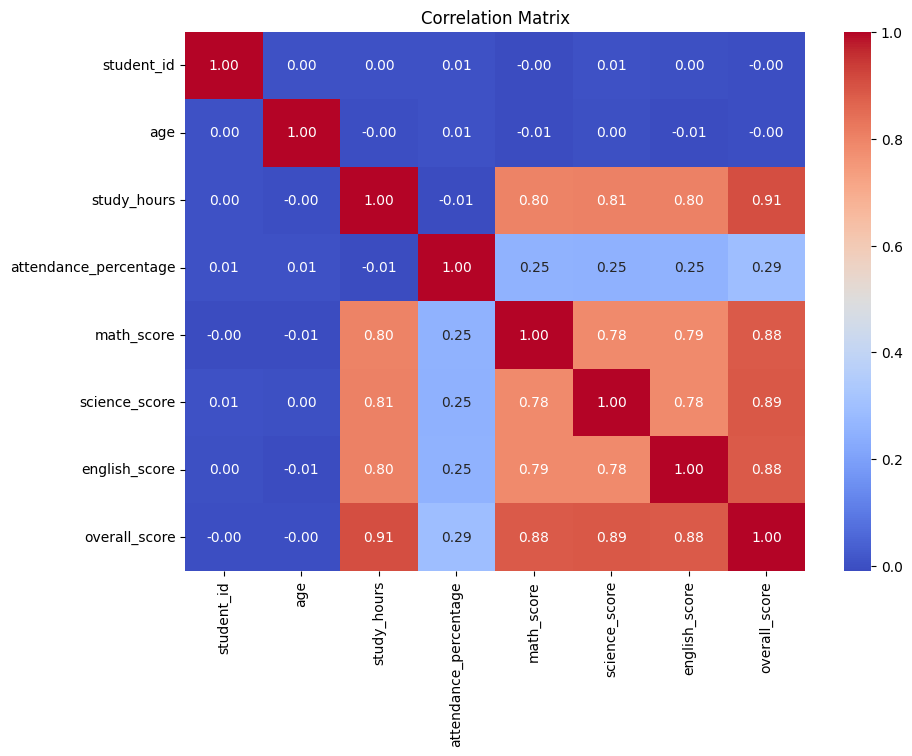

In [44]:
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

### Pairplot

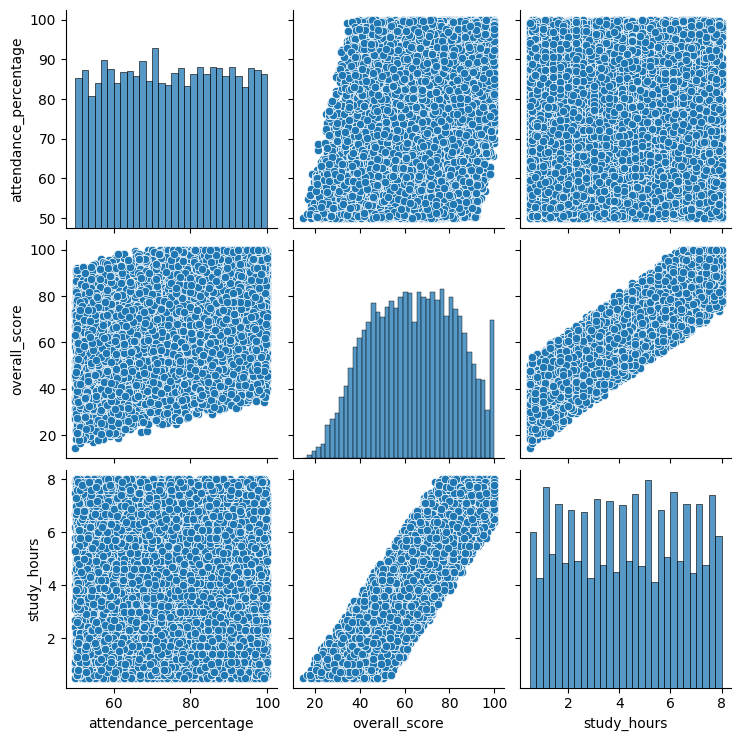

In [46]:
# Expressing overall relationships:

cols = ['attendance_percentage', 'overall_score', 'study_hours']
sns.pairplot(df[cols])
plt.savefig('../reports/pairplot.png')
plt.show()


### Histogram of Marks Distribution

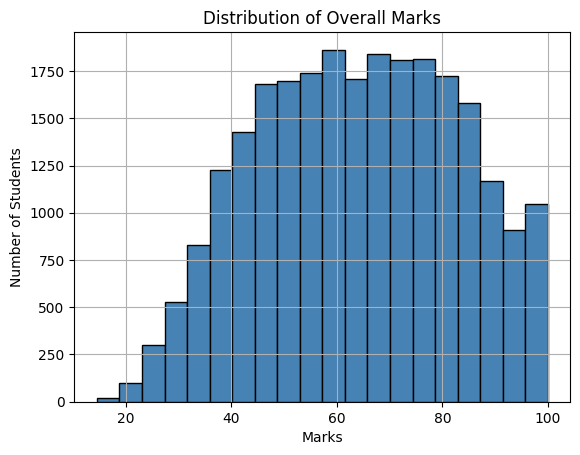

In [47]:
df['overall_score'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Overall Marks')
plt.xlabel('Marks')
plt.ylabel('Number of Students')
plt.savefig('../reports/marks_histogram.png')
plt.show()

## Phase 3 : Feature Engineering

### Creating New Columns:

In [55]:
# Average score across all assessments
df['average_score'] = df[['math_score','science_score','english_score']].mean(axis=1)

# Risk category
def risk_category(overall_score):
    if overall_score < 40:
        return 'At Risk'
    elif overall_score < 60:
        return 'Needs Improvement'
    else:
        return 'Safe'

df['risk_category'] = df['overall_score'].apply(risk_category)

# Performance level
def performance_level(overall_score):
    if overall_score >= 75:
        return 'High'
    elif overall_score >= 50:
        return 'Medium'
    else:
        return 'Low'

df['performance_level'] = df['average_score'].apply(performance_level)

print(df[['average_score', 'risk_category', 'performance_level']].head(10))

   average_score      risk_category performance_level
0      51.700000  Needs Improvement            Medium
1      63.733333               Safe            Medium
2      86.333333               Safe              High
3      42.200000  Needs Improvement               Low
4      23.866667            At Risk               Low
5      64.566667               Safe            Medium
6      36.833333            At Risk               Low
7      56.733333               Safe            Medium
8      50.633333  Needs Improvement            Medium
9      74.533333               Safe            Medium


### Visualizing at-risk students:

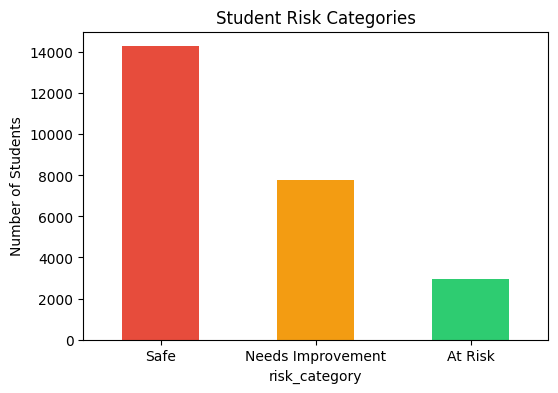

In [56]:
plt.figure(figsize=(6, 4))
df['risk_category'].value_counts().plot(kind='bar', color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Student Risk Categories')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.savefig('../reports/risk_categories.png')
plt.show()

### Saving final enriched dataset:

In [57]:
df.to_csv('../data/cleaned_data.csv', index=False)
print("Final dataset with new features saved!")

Final dataset with new features saved!
